In [ ]:
!wget https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv

--2026-03-12 16:06:20--  https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv
Resolving storage.googleapis.com (storage.googleapis.com)... 74.125.69.207, 64.233.181.207, 173.194.193.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|74.125.69.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 150828752 (144M) [text/csv]
Saving to: ‘creditcard.csv’

creditcard.csv      100%[===================>] 143.84M   244MB/s    in 0.6s    

2026-03-12 16:06:21 (244 MB/s) - ‘creditcard.csv’ saved [150828752/150828752]



# End-to-End Credit Card Fraud Detection System

## Problem Statement

Credit card fraud is a major financial risk for banks and payment systems. Fraudulent transactions can cause significant financial losses and damage customer trust.

The objective of this project is to build a machine learning model that can detect fraudulent credit card transactions.

One of the main challenges in this dataset is that it is highly imbalanced. Fraudulent transactions represent less than 1% of the total transactions.

The goal of this project is to develop a fraud detection system that can accurately identify fraudulent transactions while minimizing false negatives.

## Dataset Loading and Initial Exploration

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("creditcard.csv")

print("Shape:", df.shape)
df.head()

Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## Class Distribution Analysis

In [ ]:
df['Class'].value_counts()

,count
Class,
0,284315
1,492


## Class Distribution Percentage

In [ ]:
df['Class'].value_counts(normalize=True) * 100

,proportion
Class,
0,99.827251
1,0.172749


## Dataset Information

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

##Missing Values Check

In [ ]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


##Statistical Summary of Dataset

In [ ]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


## Class Distribution Analysis

In [ ]:
df['Class'].value_counts()

,count
Class,
0,284315
1,492


## Visualizing Class Distribution

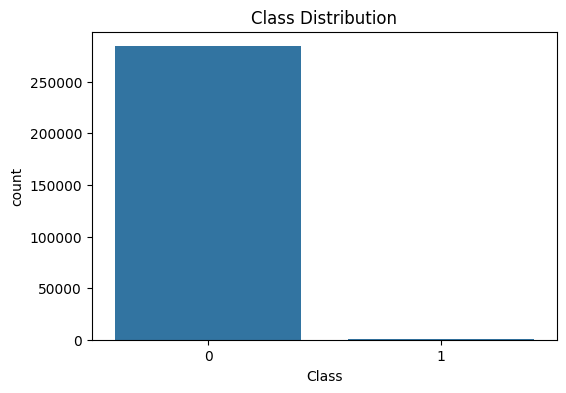

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=df)
plt.title("Class Distribution")
plt.show()

## Feature-Target Separation and Train-Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train class distribution:")
print(y_train.value_counts())

print("\nTest class distribution:")
print(y_test.value_counts())

Train class distribution:
Class
0    227451
1       394
Name: count, dtype: int64

Test class distribution:
Class
0    56864
1       98
Name: count, dtype: int64


## Feature Scaling using RobustScaler

In [ ]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
X_train['Amount'] = scaler.fit_transform(X_train[['Amount']])
X_test['Amount'] = scaler.transform(X_test[['Amount']])

X_train[['Amount']].describe()

,Amount
count,227845.000000
mean,0.921034
std,3.489528
min,-0.306193
25%,-0.227697
50%,0.000000
75%,0.772303
max,357.260404


## Handling Class Imbalance using SMOTE

In [ ]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)

X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print("Resampled class distribution:")
print(y_train_res.value_counts())

Resampled class distribution:
Class
0    227451
1    227451
Name: count, dtype: int64


## Baseline Model Training – Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_res, y_train_res)

y_pred = lr.predict(X_test)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nROC-AUC Score:", roc_auc_score(y_test, lr.predict_proba(X_test)[:,1]))

Confusion Matrix:
[[56218   646]
 [   10    88]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     56864
           1       0.12      0.90      0.21        98

    accuracy                           0.99     56962
   macro avg       0.56      0.94      0.60     56962
weighted avg       1.00      0.99      0.99     56962


ROC-AUC Score: 0.9763951655507448


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## Training Random Forest Classifier

In [ ]:
from sklearn.ensemble import RandomForestClassifier

## Training Random Forest Model

In [ ]:
rf = RandomForestClassifier(
    n_estimators=50,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

rf.fit(X_train_res, y_train_res)

RandomForestClassifier(class_weight='balanced', n_estimators=50, n_jobs=-1,
                       random_state=42)

## Checking Test Variables in the Notebook

In [ ]:
print([var for var in dir() if "test" in var])

['X_test', 'train_test_split', 'y_test']


## Random Forest Model Prediction

In [ ]:
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

## Random Forest Model Evaluation

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))
print("\nROC-AUC Score:", roc_auc_score(y_test, y_prob_rf))

Confusion Matrix:
 [[56847    17]
 [   17    81]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.83      0.83        98

    accuracy                           1.00     56962
   macro avg       0.91      0.91      0.91     56962
weighted avg       1.00      1.00      1.00     56962


ROC-AUC Score: 0.9709606989250399


## Threshold Tuning for Fraud Detection

In [ ]:
import numpy as np
from sklearn.metrics import classification_report

thresholds = [0.3, 0.4, 0.5, 0.6]

for t in thresholds:
    y_pred_custom = (y_prob_rf >= t).astype(int)
    print(f"\nThreshold: {t}")
    print(classification_report(y_test, y_pred_custom))


Threshold: 0.3
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.69      0.88      0.77        98

    accuracy                           1.00     56962
   macro avg       0.84      0.94      0.89     56962
weighted avg       1.00      1.00      1.00     56962


Threshold: 0.4
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.79      0.88      0.83        98

    accuracy                           1.00     56962
   macro avg       0.89      0.94      0.92     56962
weighted avg       1.00      1.00      1.00     56962


Threshold: 0.5
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.82      0.83      0.82        98

    accuracy                           1.00     56962
   macro avg       0.91      0.91      0.91     56962
weighted avg       1.00   

## Feature Importance Analysis using Random Forest

   Feature  Importance
14     V14    0.305528
10     V10    0.113956
4       V4    0.100266
3       V3    0.086788
17     V17    0.084995
12     V12    0.074145
16     V16    0.050008
2       V2    0.023618
9       V9    0.022402
11     V11    0.019042


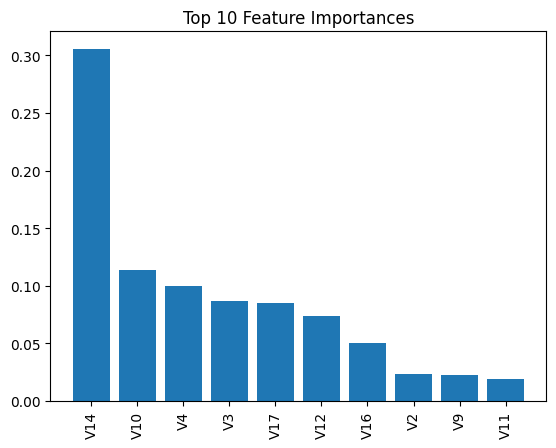

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Feature Importance nikaalna
importances = rf.feature_importances_

# Feature names
feature_names = X.columns

# DataFrame banana
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# Sort karna
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Top 10 features
top_features = feature_importance_df.head(10)

print(top_features)

# Plot karna
plt.figure()
plt.bar(top_features['Feature'], top_features['Importance'])
plt.xticks(rotation=90)
plt.title("Top 10 Feature Importances")
plt.show()

## ROC Curve Analysis

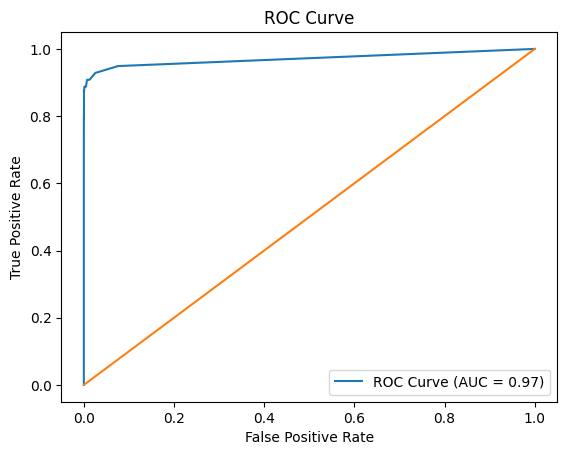

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_prob_rf)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

# Project Summary

In this project, we developed a machine learning pipeline to detect fraudulent credit card transactions.

We first performed exploratory data analysis (EDA) to understand the dataset and observed a severe class imbalance between fraudulent and non-fraudulent transactions.

To address this imbalance, we applied SMOTE (Synthetic Minority Oversampling Technique) to generate synthetic fraud samples.

We then trained two machine learning models:
- Logistic Regression as a baseline model
- Random Forest as an advanced ensemble model

The models were evaluated using multiple metrics such as:
- Confusion Matrix
- Precision, Recall, and F1-score
- ROC-AUC Score

The Random Forest model achieved strong performance with a high ROC-AUC score (~0.97), demonstrating its ability to effectively detect fraudulent transactions.

We also performed threshold tuning to analyze how prediction thresholds impact fraud detection performance and used feature importance analysis to understand which features contribute most to the model’s predictions.

# Future Improvements

Although the model performs well, several improvements can further enhance the system:

1. Hyperparameter tuning using GridSearchCV or RandomizedSearchCV to optimize model performance.

2. Testing additional machine learning models such as XGBoost, LightGBM, or Gradient Boosting.

3. Implementing deep learning models for fraud detection.

4. Deploying the model as a web application using Streamlit or Flask.

5. Integrating the system into a real-time fraud detection pipeline for live transaction monitoring.

6. Using explainability techniques such as SHAP or LIME to better interpret model predictions.

In [ ]:
import joblib
joblib.dump(rf, "fraud_model.pkl")

['fraud_model.pkl']